# IoT Intrusion Detection — Preprocessing Pipeline

The CIC-IoT-2023 dataset contains ~5.8 M pre-engineered network flows labelled
with 34 classes — benign traffic and 33 attack families — under a severe
class imbalance that exceeds 230:1 between the largest and smallest classes.
Every modelling decision in this project, from stratified splitting to the
use of class weights and macro-F1 as the primary metric, is a direct
consequence of that imbalance.

This notebook converts the raw sample into the exact inputs every downstream
model will consume: a cleaned dataset, a stratified 70 / 15 / 15 train /
validation / test split, a fitted preprocessor
(median imputer → Yeo-Johnson on skewed columns → standard scaler), a fitted
`LabelEncoder`, and a balanced class-weights vector. All artifacts are
serialised under `models/preprocessing/` and `data/processed/splits/` so that
the training notebooks can load them directly, without re-running any part of
the pipeline.

The data-transformation logic itself lives in `src/data_pipeline.py`; this
notebook is its narrative driver and the place where each design decision is
justified in context.

## Setup

The project root is prepended to `sys.path` so that `src/` imports resolve
regardless of whether the notebook is launched from the repository root
or from `notebooks/`. Pipeline helpers, display defaults, and the global
random seed are configured below.

In [1]:
# Auto-reload src/ modules whenever they change on disk.
# Without this, editing src/data_pipeline.py does NOT take effect in a running
# kernel — "Run All Cells" re-executes cells but Python's import cache keeps the
# old module in memory. Autoreload patches around that.
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RANDOM_STATE, TEST_SIZE, VAL_SIZE
from src.data_pipeline import (
    clean_dataset,
    describe_splits,
    detect_constant_features,
    detect_skewed_features,
    fit_preprocessor,
    inspect_dataset,
    load_dataset,
    save_artifacts,
    save_splits,
    split_dataset,
    transform_features,
)
from src.schema import LABEL_COLUMN

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Load the prepared sample

`load_dataset()` reads `data/processed/sample.parquet` and verifies that
every column declared by the canonical schema in `src/schema.py` is
present. The parquet itself is produced upstream by
`data/fetch/prepare_sample.py`, which streams the raw CSVs and
downsamples to a median-capped per-class count; that stage is out of
scope for this notebook and runs only when the raw data changes.

In [2]:

df_raw = load_dataset()
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (5838072, 48)


,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,igmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight,label
0,0.5760,"17,006.4000",5.5000,60.6000,37.8194,37.8194,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,20.7000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"13,018.8000",66.0000,"2,922.0000",828.7658,843.9207,"1,068.8000","167,629,843.5838",13.5000,40.7507,"1,193.8145","713,244.4098",1.0000,244.6000,Backdoor_Malware
1,198.7577,"49,189.4000",7.1000,81.5000,49.8226,49.8226,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,40.5000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"9,205.0000",208.8000,"4,350.0000","1,454.7051","1,335.5266","1,938.8000",0.0083,5.5000,52.7562,"1,888.7198","2,471,854.4491",0.9000,38.5000,Backdoor_Malware
2,694.9429,"11,025.8000",9.8000,144.5000,0.5178,0.5178,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4000,0.0000,2.0000,8.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,635.2000,60.0000,160.6000,99.1911,44.0256,143.6000,0.0818,5.5000,13.8851,62.2615,"3,122.5763",0.9000,38.5000,Backdoor_Malware
3,837.2362,"18,463.1000",8.2000,96.5000,10.1828,10.1828,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.7000,0.8000,0.0000,57.5000,95.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,553.4000,54.0000,177.2000,89.1236,51.0883,116.0000,0.0279,5.5000,13.2121,72.2498,"3,734.7784",0.7000,38.5000,Backdoor_Malware
4,788.4793,"39,576.5000",8.7000,97.9000,4.8519,4.8519,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,169.3000,340.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,440.7000,50.0000,136.4000,77.0718,29.3169,76.6000,0.0504,5.5000,12.3714,41.4604,"1,051.3344",0.9000,38.5000,Backdoor_Malware


## 2. Inspect data-quality issues before any transformation

Every issue that could silently distort training is surfaced before any
transformation runs, so that the handling of each is an explicit design
decision rather than an implicit default: missing values per feature,
`±∞` values per feature (which arise when network rates such as
`packets / duration` have a near-zero denominator), duplicate rows that
are identical across every feature and the label, and any drift between
the labels observed in the dataset and the 34-class taxonomy declared
in `src/schema.py`. The report below shows the prepared sample is
already clean — zero `NaN`s, zero infinities, six exact duplicates, and
no label drift — but the inspection step is retained as a guard should
the upstream sample ever change.

In [3]:

report = inspect_dataset(df_raw)
for key in [
    "rows", "feature_count", "label_count",
    "duplicate_row_count",
    "labels_outside_schema", "labels_missing_from_data",
]:
    print(f"{key:30s}: {report[key]}")

print("\nFeatures with NaNs:", report["null_counts_per_feature"] or "(none)")
print("Features with infs :", report["inf_counts_per_feature"] or "(none)")

rows                          : 5838072
feature_count                 : 47
label_count                   : 34
duplicate_row_count           : 6
labels_outside_schema         : []
labels_missing_from_data      : []

Features with NaNs: (none)
Features with infs : (none)


## 3. The class distribution is imbalanced by a 230:1 ratio

The largest class (`DDoS-UDP_Fragmentation`) contains 285 818 rows; the
smallest classes in the long tail contain as few as ~1 250. The
resulting 230:1 ratio is the single most important fact about this
dataset and motivates every subsequent design choice — stratified
splitting so that each split preserves the proportions, macro-F1 as the
primary reporting metric rather than accuracy, and a class-weighted
loss rather than oversampling.

The distribution is logged here so that the reader can see the
imbalance directly, but the weights used at training time are derived
later from the training split alone to avoid any leakage of
distributional information from validation or test into the classifier.

In [4]:

raw_label_counts = df_raw[LABEL_COLUMN].value_counts()
print(f"{len(raw_label_counts)} classes, max={raw_label_counts.max():,}, min={raw_label_counts.min():,}")
raw_label_counts.head(10).to_frame("count")

34 classes, max=285,818, min=1,252


,count
label,
DDoS-UDP_Fragmentation,285818
DoS-TCP_Flood,285742
DoS-SYN_Flood,285741
Mirai-greip_flood,285740
DDoS-SYN_Flood,285739
Mirai-greeth_flood,285739
DDoS-ICMP_Fragmentation,285738
DoS-UDP_Flood,285736
BenignTraffic,285733


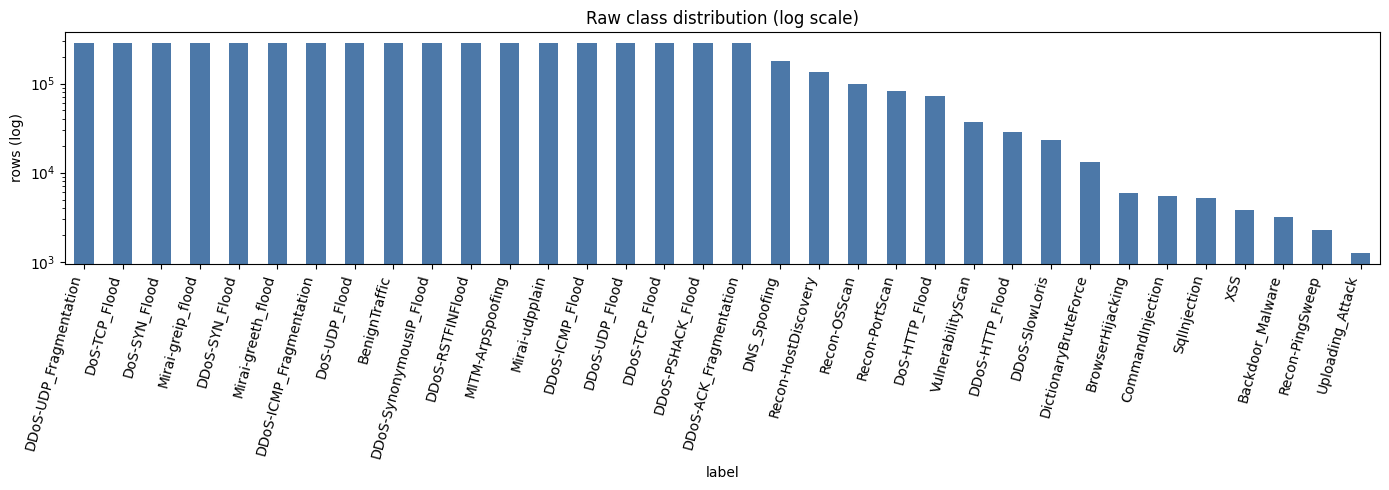

In [5]:

fig, ax = plt.subplots(figsize=(14, 5))
raw_label_counts.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_yscale("log")
ax.set_title("Raw class distribution (log scale)")
ax.set_xlabel(LABEL_COLUMN)
ax.set_ylabel("rows (log)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## 4. Clean the dataset

Because the prepared parquet is already schema-validated upstream by
`prepare_sample.py`, `clean_dataset()` is deliberately minimal: it
drops rows with a missing label, strips whitespace and removes empty
labels, and removes exact duplicate rows. Numeric coercion and
infinity replacement are not performed here, as they would be dead
code on the already-clean sample.

Robustness at inference time — where incoming traffic may produce
`NaN` or `±∞` for features such as `rate = packets / duration` with a
near-zero denominator — is delegated instead to the fitted
preprocessor's `SimpleImputer(median)`. Separating the two concerns
keeps training honest about the data it sees, while inference remains
robust to the less-controlled data it may encounter.

In [6]:
df_clean = clean_dataset(df_raw)

print(f"Raw rows:     {len(df_raw):>10,}")
print(f"Clean rows:   {len(df_clean):>10,}")
print(f"Rows removed: {len(df_raw) - len(df_clean):>10,}")
print(f"Classes:      {df_clean[LABEL_COLUMN].nunique()}")

Raw rows:      5,838,072
Clean rows:    5,838,066
Rows removed:          6
Classes:      34


## 5. Stratified 70 / 15 / 15 split

The split is performed before any feature transformation, so that every
statistic later used by the preprocessor — medians for imputation,
Yeo-Johnson λ parameters, standardisation mean and variance — is
estimated exclusively from training rows. Fitting any transformer on
data that subsequently appears in validation or test would constitute
data leakage and inflate the reported metrics.

Stratification is applied on the label so that every class retains its
proportion in each of the three splits. Without stratification, a
random draw could place nearly all rows of a rare class such as
`Uploading_Attack` (≈ 1 250 rows) into a single split, leaving the
others with none and making those classes impossible to evaluate.

In [7]:
splits = split_dataset(df_clean, val_size=VAL_SIZE, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"X_train: {splits.X_train.shape}")
print(f"X_val:   {splits.X_val.shape}")
print(f"X_test:  {splits.X_test.shape}")
describe_splits(splits).head(15)

X_train: (4086646, 47)
X_val:   (875710, 47)
X_test:  (875710, 47)


,train,val,test
label,,,
Backdoor_Malware,2252,483,483
BenignTraffic,200013,42860,42860
BrowserHijacking,4101,879,879
CommandInjection,3787,811,811
DDoS-ACK_Fragmentation,199573,42765,42766
DDoS-HTTP_Flood,20153,4319,4318
DDoS-ICMP_Flood,200007,42858,42858
DDoS-ICMP_Fragmentation,200016,42861,42861
DDoS-PSHACK_Flood,200004,42858,42858


## 6. Detect constant and skewed features on the training split

Two structural properties of the feature set are characterised here,
both using only the training rows. Constant features — columns with a
single unique value — are reported rather than dropped. Dropping them
would diverge the inference schema from the training schema for no
modelling benefit: tree ensembles ignore them naturally, and linear
models zero-weight them after standardisation.

Skewed features are identified by a three-gate rule. A column qualifies
for the Yeo-Johnson transform only if its absolute skewness exceeds
`SKEW_THRESHOLD` (heavy tail), it has at least `SKEW_MIN_UNIQUE`
distinct values (continuous rather than indicator-like), and its
fraction of non-zero rows exceeds `SKEW_MIN_NONZERO_FRACTION` (not a
sparse flag column). The second and third gates are necessary because
this feature set contains protocol flags and TCP-flag counters that are
zero for nearly every row and therefore register extreme mathematical
skewness despite having no continuum of values to reshape. Yeo-Johnson
is built for long-tailed continuous distributions and cannot normalise
a sparse indicator, so applying it there wastes compute with no
statistical benefit.

In [8]:
constant_features = detect_constant_features(splits.X_train)
skewed_features = detect_skewed_features(splits.X_train, exclude=constant_features)

print(f"Constant features ({len(constant_features)}):")
print("  " + (", ".join(constant_features) if constant_features else "(none)"))
print(f"\nSkewed features ({len(skewed_features)}):")
print("  " + (", ".join(skewed_features) if skewed_features else "(none)"))

Constant features (1):
  igmp

Skewed features (19):
  flow_duration, header_length, protocol_type, duration, rate, srate, ack_count, syn_count, fin_count, urg_count, rst_count, tot_sum, min, max, avg, std, tot_size, radius, covariance


## 7. Fit the preprocessor on the training split

`fit_preprocessor()` composes three transformers into a single
`sklearn.Pipeline`: median imputation, Yeo-Johnson on the columns
identified as skewed in the previous step, and standard scaling across
all features. In the same call, a `LabelEncoder` is fitted and balanced
class weights are computed according to
`w_c = N / (K · n_c)`.

All three artifacts — pipeline, label encoder, and weights vector —
are derived exclusively from the training split. Validation and test
rows do not contribute to any estimated parameter and will only be
seen by the subsequent `.transform()` call. Fitting runs over roughly
4 M rows; the dominant cost is `PowerTransformer`, which estimates λ
per skewed column by maximum likelihood.

In [9]:
artifacts = fit_preprocessor(splits.X_train, splits.y_train)

print(f"Feature columns:            {len(artifacts.feature_columns)}")
print(f"Skewed (power-transformed): {len(artifacts.skewed_features)}")
print(f"Constant (kept, flagged):   {len(artifacts.constant_features)}")
print(f"Classes (label_encoder):    {len(artifacts.label_encoder.classes_)}")

Feature columns:            47
Skewed (power-transformed): 19
Constant (kept, flagged):   1
Classes (label_encoder):    34


## 8. Apply the fitted preprocessor to every split

The single fitted pipeline is applied to each of the three splits. The
output retains the original feature names and order so that downstream
models can continue to refer to features by name rather than by
position. The printed mean (≈ 0) and standard deviation (≈ 1) on the
transformed training set confirm that standardisation has worked as
expected across the full feature set.

In [10]:
X_train_t = transform_features(artifacts.preprocessor, splits.X_train)
X_val_t   = transform_features(artifacts.preprocessor, splits.X_val)
X_test_t  = transform_features(artifacts.preprocessor, splits.X_test)

y_train_enc = artifacts.label_encoder.transform(splits.y_train)
y_val_enc   = artifacts.label_encoder.transform(splits.y_val)
y_test_enc  = artifacts.label_encoder.transform(splits.y_test)

print("X_train_t:", X_train_t.shape,
      "| mean \u2248", round(float(X_train_t.mean().mean()), 3),
      "| std \u2248", round(float(X_train_t.std().mean()), 3))
print("X_val_t:  ", X_val_t.shape)
print("X_test_t: ", X_test_t.shape)

X_train_t: (4086646, 47) | mean ≈ 0.0 | std ≈ 0.979
X_val_t:   (875710, 47)
X_test_t:  (875710, 47)


## 9. Class weights rather than oversampling

The 230:1 imbalance is handled at the loss level rather than by
manipulating the training data. Naive oversampling would duplicate
each `Uploading_Attack` row roughly 230 times, allowing the classifier
to memorise specific rare-class rows — high training accuracy, poor
generalisation — while synthetic interpolation via SMOTE is ill-suited
to the mix of binary protocol flags, integer packet counts, and ratios
in this feature set, since a linear interpolation between two real
flows produces flows that could not occur in the wild.

Balanced class weighting rescales each sample's contribution to the
loss by `w_c = N / (K · n_c)`. Rare classes receive large weights,
common classes receive small weights, and the training distribution
itself remains intact. Every classifier used later in this project —
`LogisticRegression`, tree ensembles, and the PyTorch MLP — accepts
either `class_weight="balanced"` or an explicit weights dictionary;
the dictionary is persisted in the manifest so that training code can
consume it directly without recomputation.

In [11]:

weights_df = (
    pd.Series(artifacts.class_weights, name="weight")
    .sort_values(ascending=False)
    .to_frame()
)
weights_df.head(10)

,weight
Uploading_Attack,137.2094
Recon-PingSweep,75.8810
Backdoor_Malware,53.3728
XSS,44.6491
SqlInjection,32.7419
CommandInjection,31.7390
BrowserHijacking,29.3088
DictionaryBruteForce,13.1433
DDoS-SlowLoris,7.3299
DDoS-HTTP_Flood,5.9641


## 10. Visual sanity check on the Yeo-Johnson transform

A paired histogram is produced for the feature with the largest
absolute training-set skewness, before and after the preprocessing
pipeline. The raw distribution is expected to be compressed into a
narrow bin with a long thin tail; the transformed distribution should
appear visibly more symmetric and centred near zero with unit
variance. Confirming this visually avoids relying on faith that the
per-column maximum-likelihood λ estimates have converged to something
useful across every skewed feature.

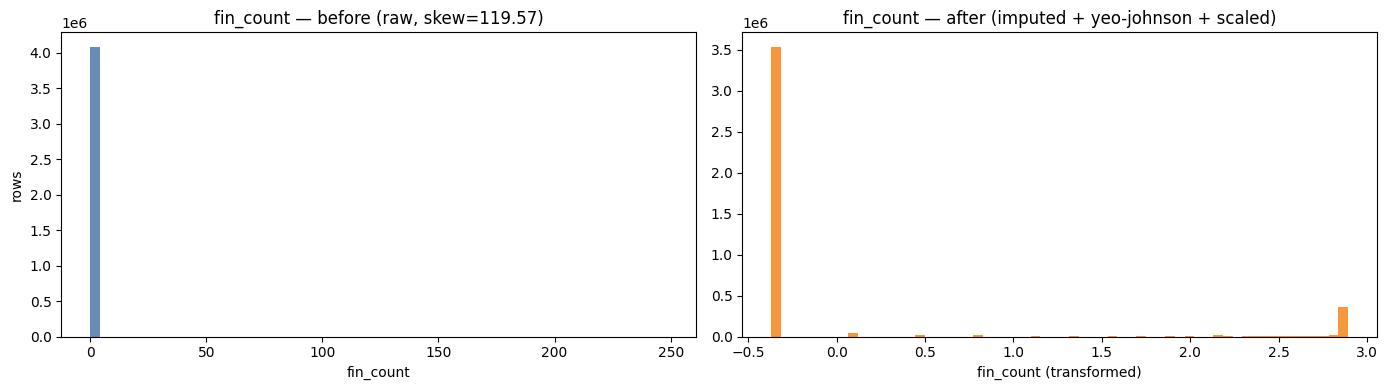

In [12]:

if artifacts.skewed_features:
    ranked = (
        splits.X_train[artifacts.skewed_features].skew().abs().sort_values(ascending=False)
    )
    feature_to_plot = ranked.index[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(splits.X_train[feature_to_plot].dropna(), bins=60, color="#4C78A8", alpha=0.85)
    axes[0].set_title(f"{feature_to_plot} — before (raw, skew={ranked.iloc[0]:.2f})")
    axes[0].set_xlabel(feature_to_plot)
    axes[0].set_ylabel("rows")

    axes[1].hist(X_train_t[feature_to_plot].dropna(), bins=60, color="#F58518", alpha=0.85)
    axes[1].set_title(f"{feature_to_plot} — after (imputed + yeo-johnson + scaled)")
    axes[1].set_xlabel(feature_to_plot + " (transformed)")

    plt.tight_layout()
    plt.show()
else:
    print("No skewed features detected — nothing to plot.")

## 11. Persist preprocessing artifacts and transformed splits

Two directories are written so that downstream training and inference
never need to re-run the pipeline. Under `models/preprocessing/`, the
fitted pipeline, the label encoder, and a human-readable manifest
(feature list, skewed and constant columns, classes, class weights)
are saved for reuse at both training and inference time. Under
`data/processed/splits/`, each split is written as a single parquet
file containing the transformed features alongside both the string
label and its integer encoding, together with a manifest of row counts
and column names.

From this point on, every downstream notebook is a single
`src.data_pipeline.load_split(...)` away from ready-to-train tensors.

In [13]:

from dataclasses import replace

# We persist the transformed features so downstream code loads ready-to-train data.
splits_transformed = replace(
    splits,
    X_train=X_train_t,
    X_val=X_val_t,
    X_test=X_test_t,
)

artifacts_dir = save_artifacts(artifacts)
splits_dir = save_splits(splits_transformed, artifacts.label_encoder)

print(f"Artifacts saved to: {artifacts_dir}")
print(f"Splits saved to:    {splits_dir}")

Artifacts saved to: C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\models\preprocessing
Splits saved to:    C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\data\processed\splits
